In [1]:
import os
import sys
from pathlib import Path

current_dir = Path(os.getcwd())


if (current_dir.parent / "src").exists():
    PROJECT_ROOT = str(current_dir.parent)

elif (current_dir / "src").exists():
    PROJECT_ROOT = str(current_dir)

else:
    raise FileNotFoundError(
        "Could not locate project root containing 'src/'. Please run this notebook from the 'notebooks/' folder."
    )


if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added project root to path: {PROJECT_ROOT}")

Added project root to path: /Users/shivakumarjagadish/Developer/Projects/Thermal-UAV


In [2]:
import matplotlib.pyplot as plt
import numpy as np

%load_ext dotenv
%dotenv


try:
    from src.data_pipeline import VedaiDataset

    print("Successfully imported src.data_pipeline")

except ImportError as e:
    print("\nFATAL ERROR: Could not import from 'src'.")
    print(
        "Double-check that your 'src' folder exists in the PROJECT_ROOT listed above.\n"
    )
    raise e

Successfully imported src.data_pipeline


In [3]:
RAW_DATA_PATH = os.environ.get("TEST_DATA_PATH")

if not RAW_DATA_PATH:
    print("ERROR: TEST_DATA_PATH is not set in your .env file.")
    print(
        "Please create a .env file in the project root with: TEST_DATA_PATH=data/raw/vedai"
    )
    raise ValueError("Missing environment variable TEST_DATA_PATH")

DATA_PATH = os.path.join(PROJECT_ROOT, RAW_DATA_PATH)

print(f"Looking for dataset at: {DATA_PATH}")

if not os.path.exists(DATA_PATH):
    print("\nERROR: Path not found!")
    print(f"We tried looking here: {DATA_PATH}")
    print("Please ensure you have:")
    print("  1. Created the 'data/raw/vedai' folder in your project root.")
    print("  2. Unzipped the VEDAI dataset into it.")
    raise FileNotFoundError(f"Path not found: {DATA_PATH}")

try:
    dataset = VedaiDataset(root_dir=DATA_PATH, transform=None)
    print(f"Successfully loaded VEDAI dataset with {len(dataset)} samples.")

except Exception as e:
    print(f"Failed to initialize VedaiDataset: {e}")
    raise e

Looking for dataset at: /Users/shivakumarjagadish/Developer/Projects/Thermal-UAV/data/raw/vedai
Successfully loaded VEDAI dataset with 1246 samples.


In [4]:
def visualize_thermal_noise(dataset_obj, idx):
    """
    Loads a thermal image from the dataset object and displays it in three ways
    to help identify noise and artifacts:
    1. Inferno (Standard thermal view - how a human usually sees it)
    2. Grayscale (Raw pixel intensities - good for spotting dead pixels)
    3. Contrast Enhanced (Histogram equalization - CRITICAL for finding stripe noise)
    """

    try:
        sample = dataset_obj[idx]
        thermal_img = sample[1]

    except Exception as e:
        print(f"❌ Error loading sample at index {idx}: {e}")
        return

    thermal_np = np.array(thermal_img)

    if thermal_np.ndim == 3:
        thermal_np = thermal_np[:, :, 0]

    fig, ax = plt.subplots(1, 3, figsize=(24, 8))

    im0 = ax[0].imshow(thermal_np, cmap="inferno")
    ax[0].set_title(f"Sample {idx}: Standard Thermal (Inferno)", fontsize=14)
    ax[0].axis("off")
    fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[1].imshow(thermal_np, cmap="gray")
    ax[1].set_title(f"Sample {idx}: Raw Grayscale", fontsize=14)
    ax[1].axis("off")
    fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    img_min, img_max = thermal_np.min(), thermal_np.max()
    if img_max - img_min > 0:
        img_norm = (thermal_np - img_min) / (img_max - img_min)
    else:
        img_norm = thermal_np

    px_min, px_max = np.percentile(img_norm, (1, 99))

    if px_max - px_min > 1e-6:
        img_eq = np.clip((img_norm - px_min) / (px_max - px_min), 0, 1)
    else:
        img_eq = img_norm

    im2 = ax[2].imshow(img_eq, cmap="gray")
    ax[2].set_title(f"Sample {idx}: Contrast Enhanced (Artifact View)", fontsize=14)
    ax[2].axis("off")
    fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


print("Visualization function defined successfully.")

Visualization function defined successfully.



--- Analyzing Sample 0 ---


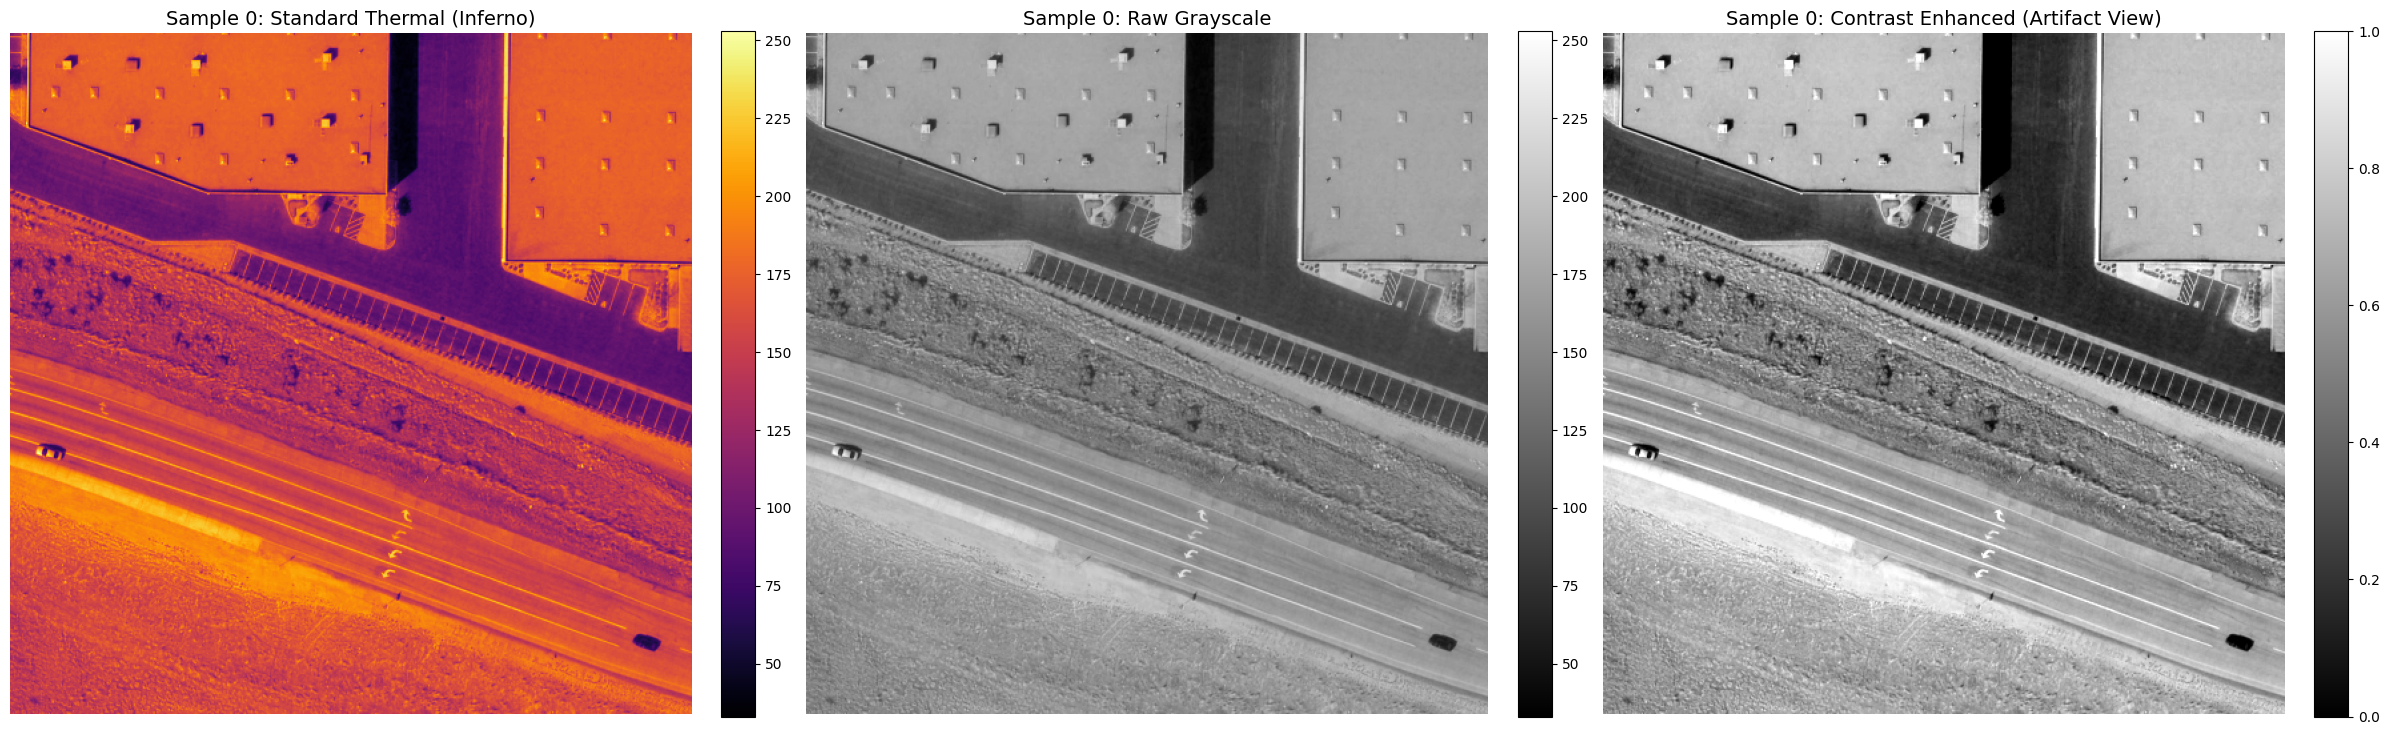


--- Analyzing Sample 100 ---


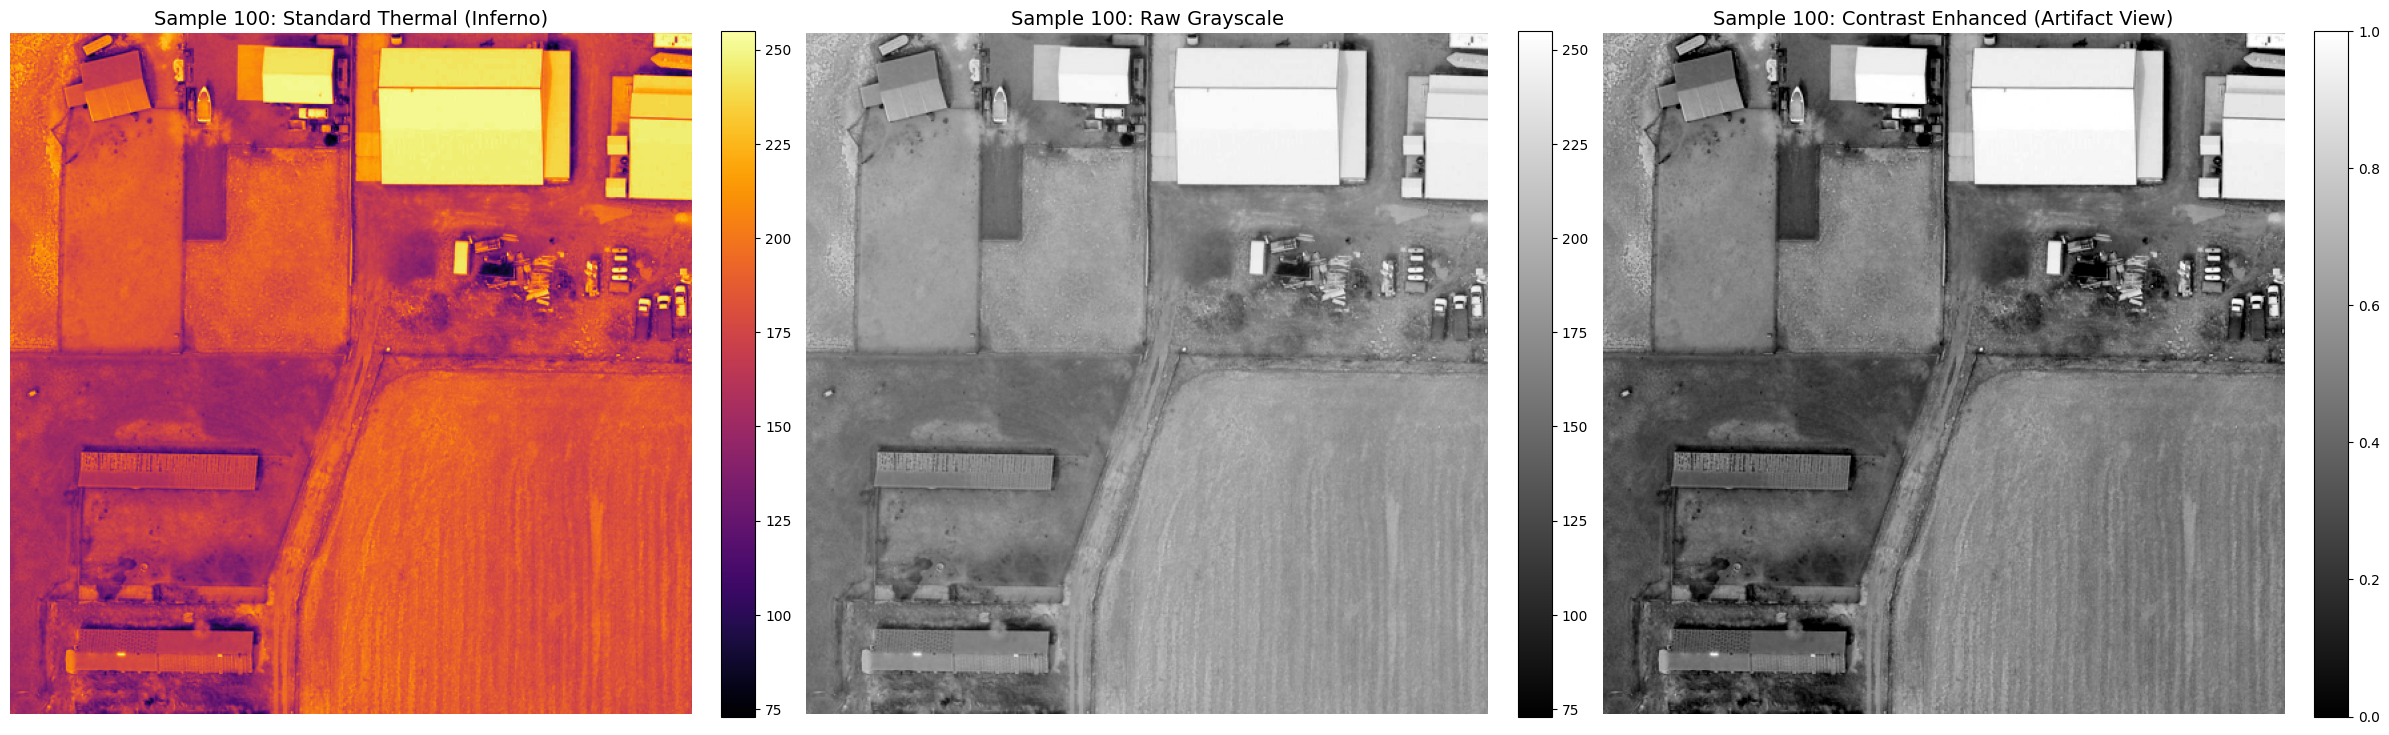


--- Analyzing Sample 500 ---


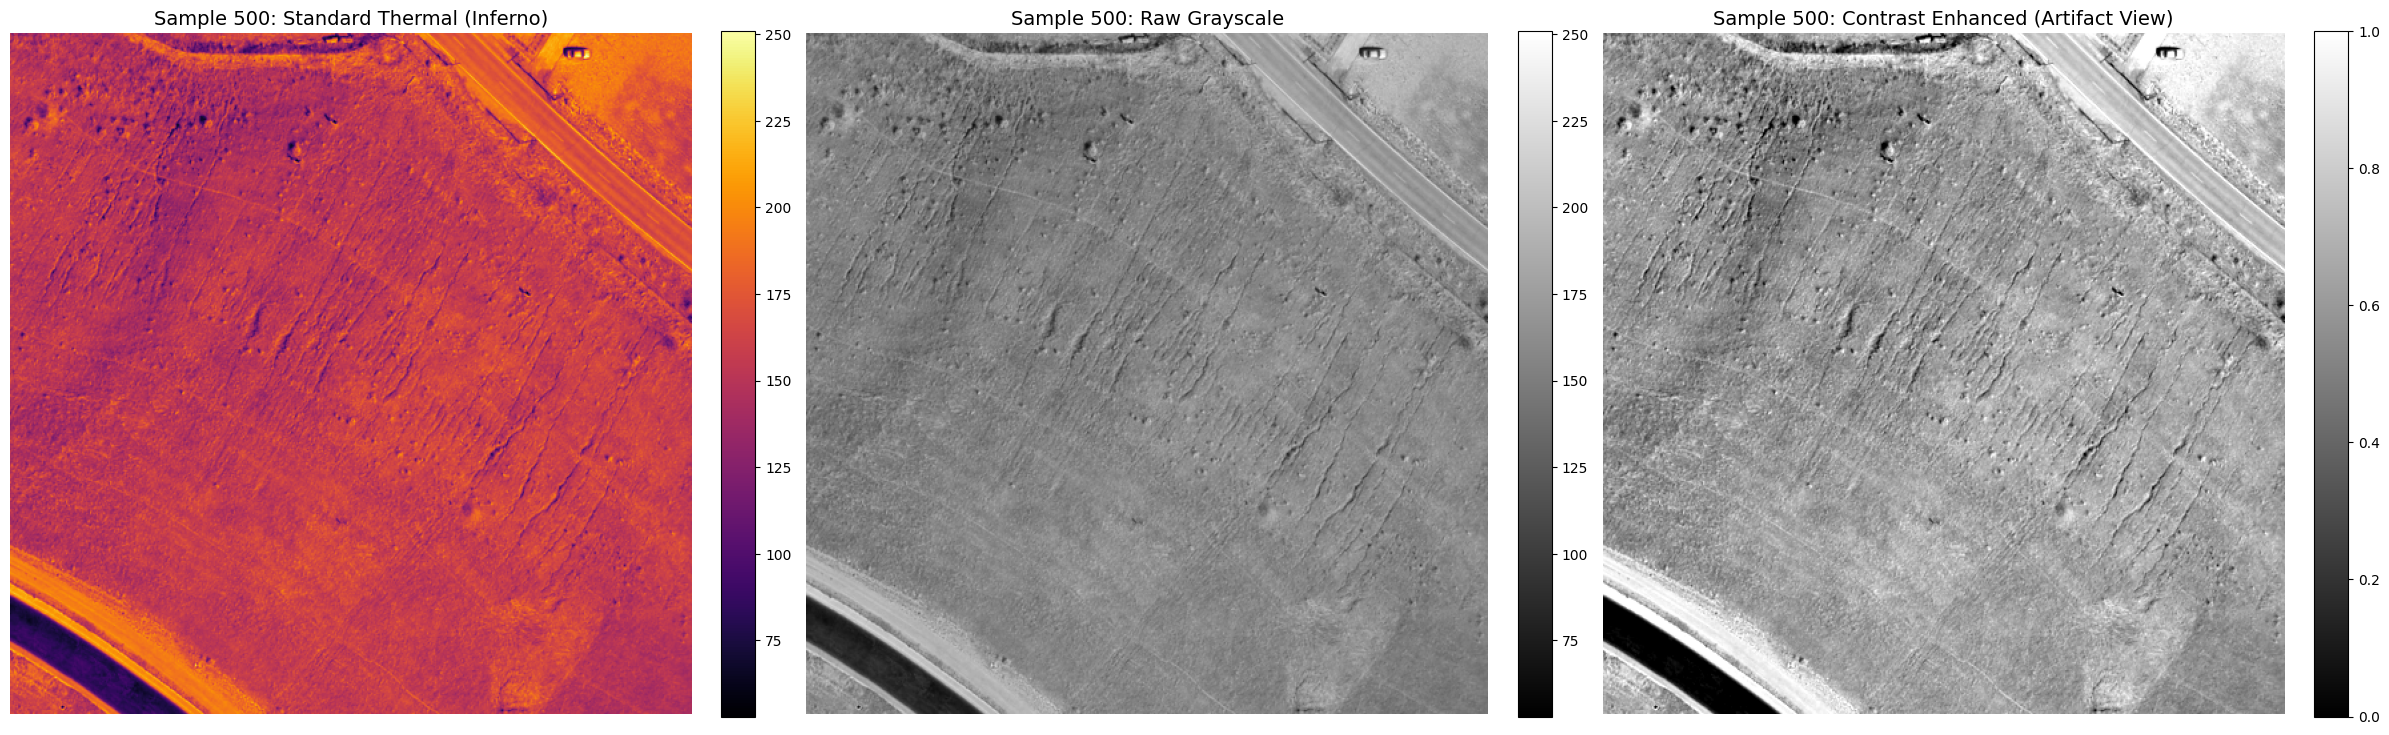

In [5]:
indices_to_check = [0, 100, 500]

for idx in indices_to_check:
    print(f"\n--- Analyzing Sample {idx} ---")
    visualize_thermal_noise(dataset, idx=idx)

# Thermal Noise Analysis Findings

**Analyst:** Khaleel and Shivakumar
**Date:** 2025-11-06

## Observations Checklist

Run the visualization on at least 10 different images. Look closely at the "Contrast Enhanced" view.

| Artifact Type | Observed? (Yes/No) | Severity (Low/Med/High) | Sample Indices (Examples) |
| :--- | :--- | :--- | :--- |
| **Vignetting** (Darker corners) | **No** | - | |
| **Stripe Noise** (Vertical fixed lines) | **Yes** | **Low** | 0, 100 (visible in flat areas like roads/fields) |
| **Stripe Noise** (Horizontal fixed lines) | **No** | - | |
| **Stuck Pixels** (Bright/Dark dots that never move) | **No** | - | (Checked multiple indices, none obvious) |
| **General Grain** (Random static noise) | **No** | - | Image is very clean otherwise |

## Detailed Notes
* The VEDAI data is very high quality and sharp.
* However, contrast enhancement reveals **mild vertical striping** (Fixed Pattern Noise).
* This is most visible in large uniform areas like roads (Sample 0) and fields (Sample 100).
* No obvious dead pixels or heavy vignetting were found in the sampled images.

## Conclusion for NUC (Phase 2)
Based on these findings, our NUC algorithm must prioritize:
* [x] **Destriping** (Mild vertical stripe correction is needed)
* [ ] Dead Pixel Replacement (Not currently needed)
* [ ] Flat-field correction (Not currently needed)

# :)